# Manual review: residual ambiguous clips

Whatever's left after area+motion selection (baked into extraction) and the wrist-velocity tiebreak. Shows every detected track on the frame, not just the top two - the real hitter sometimes scores too low to make a top-2 cut. Pick the correct letter, or SKIP if none of them are actually the shot-performing player (they were never tracked at all).

In [1]:
import os
import sys
import glob

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

sys.path.insert(0, "/workspace/badminton-honours-project/pipeline")
from pose_extraction_utils import (
    _track_area, _track_peak_motion, standardize_indices,
    smooth_keypoint_sequence, inference_topdown_safe,
)


In [2]:
from ultralytics import YOLO
from mmpose.apis import init_model

CHECKPOINT_DIR = "/workspace/checkpoints"
pose_config = glob.glob(os.path.join(CHECKPOINT_DIR, "rtmpose-m*coco-256x192*.py"))[0]
pose_checkpoint = glob.glob(os.path.join(CHECKPOINT_DIR, "rtmpose-m*256x192*.pth"))[0]

detector = YOLO("yolov8m.pt")
pose_model = init_model(pose_config, pose_checkpoint, device="cuda:0")


/workspace/venv/lib/python3.10/site-packages/mmengine/utils/package_utils.py:48: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


Loads checkpoint by local backend from path: /workspace/checkpoints/rtmpose-m_simcc-coco_pt-aic-coco_420e-256x192-d8dd5ca4_20230127.pth


### load the remaining ambiguous clips

In [3]:
log = pd.read_csv("/workspace/data/extraction_log.csv")
if "excluded" not in log.columns:
    log["excluded"] = False

remaining = log[(log["track_area_ratio"] > 0.6) & (~log["excluded"])].reset_index(drop=True)
print(f"{len(remaining)} clips left to review")
remaining[["filepath", "class_name", "track_area_ratio", "selection_method"]]


74 clips left to review


,filepath,class_name,track_area_ratio,selection_method
0,00_Short Serve/2022-08-30_19-19-43_dataset_set...,00_Short Serve,0.777938,wrist_tiebreak
1,00_Short Serve/2022-08-30_19-19-43_dataset_set...,00_Short Serve,0.623517,wrist_tiebreak
2,00_Short Serve/2022-08-30_19-19-43_dataset_set...,00_Short Serve,0.811112,wrist_tiebreak
3,00_Short Serve/2022-08-30_19-19-43_dataset_set...,00_Short Serve,0.847566,wrist_tiebreak
4,00_Short Serve/2022-08-30_19-35-00_dataset_set...,00_Short Serve,0.647556,wrist_tiebreak
...,...,...,...,...
69,17_Short Flat Shot/2023-05-02_20-34-08_dataset...,17_Short Flat Shot,0.715642,wrist_tiebreak
70,17_Short Flat Shot/2023-05-02_20-34-08_dataset...,17_Short Flat Shot,0.800964,wrist_tiebreak
71,17_Short Flat Shot/2023-05-02_20-34-08_dataset...,17_Short Flat Shot,0.963395,wrist_tiebreak
72,17_Short Flat Shot/2023-05-02_20-34-08_dataset...,17_Short Flat Shot,0.734214,wrist_tiebreak


### review loop

Run once per clip. Set `choice` to a letter shown, or "SKIP", then run the next cell.

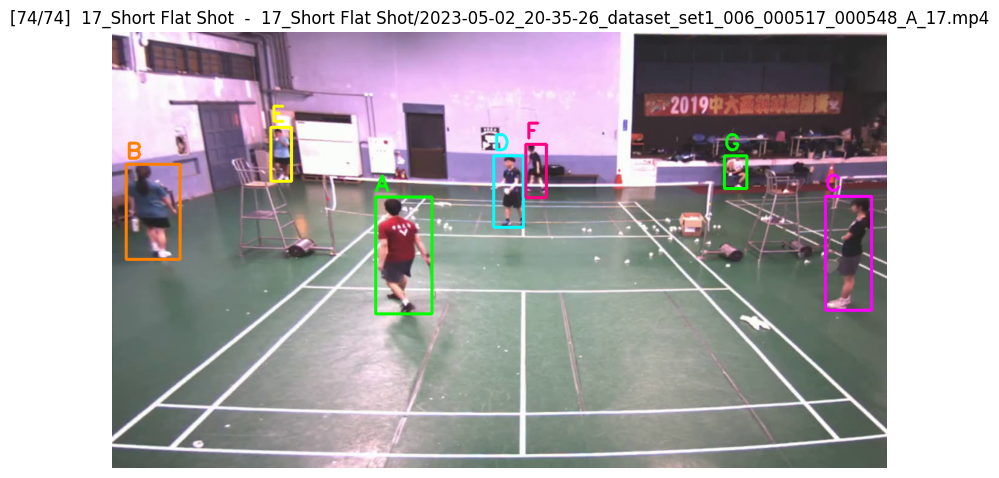

letters shown: ['A', 'B', 'C', 'D', 'E', 'F', 'G']
set choice to one of those letters, or "SKIP", then run the next cell


In [152]:
if "review_idx" not in dir():
    review_idx = 0

row = remaining.iloc[review_idx]
video_path = os.path.join("/workspace/data/raw", row["filepath"])

all_frames = []
track_boxes = {}
results = detector.track(
    source=video_path, persist=False, tracker="bytetrack.yaml",
    classes=[0], verbose=False, stream=True,
)
for frame_idx, r in enumerate(results):
    all_frames.append(r.orig_img)
    if r.boxes is None or r.boxes.id is None:
        continue
    for box, tid in zip(r.boxes.xyxy.cpu().numpy(), r.boxes.id.cpu().numpy()):
        track_boxes.setdefault(int(tid), {})[frame_idx] = box

scores = {tid: _track_area(f) + _track_peak_motion(f) for tid, f in track_boxes.items()}
ranked = sorted(scores.items(), key=lambda kv: kv[1], reverse=True)

letters = [chr(ord("A") + i) for i in range(len(ranked))]
letter_to_id = {letter: tid for letter, (tid, _) in zip(letters, ranked)}
colors = [(0,255,0), (0,128,255), (255,0,255), (255,255,0), (0,255,255), (128,0,255)]

common = set.intersection(*[set(track_boxes[tid].keys()) for tid, _ in ranked]) if len(ranked) > 1 else set(track_boxes[ranked[0][0]].keys())
if not common:
    common = set(track_boxes[ranked[0][0]].keys())
mid_frame = sorted(common)[len(common) // 2]
frame = all_frames[mid_frame].copy()

for i, (tid, _) in enumerate(ranked):
    if mid_frame not in track_boxes[tid]:
        continue
    box = [int(v) for v in track_boxes[tid][mid_frame]]
    color = colors[i % len(colors)]
    cv2.rectangle(frame, (box[0], box[1]), (box[2], box[3]), color, 3)
    cv2.putText(frame, letters[i], (box[0], max(0, box[1]-10)), cv2.FONT_HERSHEY_SIMPLEX, 1.2, color, 3)

plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
plt.title(f"[{review_idx+1}/{len(remaining)}]  {row['class_name']}  -  {row['filepath']}")
plt.axis("off")
plt.show()

print(f"letters shown: {letters}")
print("set choice to one of those letters, or \"SKIP\", then run the next cell")


### make the call, then save and advance

In [153]:
choice = "A"  # <-- set to a letter above, or "SKIP", then run this cell

log_idx = log[log["filepath"] == row["filepath"]].index[0]

if choice == "SKIP":
    log.loc[log_idx, "excluded"] = True
    log.loc[log_idx, "selection_method"] = "excluded_manual_review"
    log.to_csv("/workspace/data/extraction_log.csv", index=False)
    review_idx += 1
    print(f"excluded. {review_idx}/{len(remaining)} done.")
else:
    primary_id = letter_to_id[choice]

    valid_frames = sorted(track_boxes[primary_id].keys())
    idx_map = standardize_indices(len(valid_frames), 30)

    keypoints_seq = np.zeros((30, 17, 3), dtype=np.float32)
    for out_i, vf_i in enumerate(idx_map):
        frame_idx = valid_frames[vf_i]
        frame_img = all_frames[frame_idx]
        box = track_boxes[primary_id][frame_idx]
        kps, scores_ = inference_topdown_safe(pose_model, frame_img, box)
        keypoints_seq[out_i, :, 0:2] = kps
        keypoints_seq[out_i, :, 2] = scores_

    smoothed = smooth_keypoint_sequence(keypoints_seq)

    class_name = row["class_name"]
    stem = os.path.splitext(os.path.basename(row["filepath"]))[0]
    np.save(f"/workspace/data/keypoints_raw/{class_name}/{stem}.npy", keypoints_seq)
    np.save(f"/workspace/data/keypoints_smoothed/{class_name}/{stem}.npy", smoothed)

    log.loc[log_idx, "track_area_ratio"] = 0.0
    log.loc[log_idx, "selection_method"] = "manual_review"
    log.loc[log_idx, "mean_confidence"] = float(keypoints_seq[:, :, 2].mean())
    log.loc[log_idx, "min_confidence"] = float(keypoints_seq[:, :, 2].min())
    log.to_csv("/workspace/data/extraction_log.csv", index=False)

    review_idx += 1
    print(f"saved. {review_idx}/{len(remaining)} done.")


saved. 74/74 done.


---

Once done:

```python
print("resolved:", (log['selection_method'] == 'manual_review').sum())
print("excluded:", log['excluded'].sum())
```

Then commit extraction_log.csv.

In [154]:
print("resolved:", (log['selection_method'] == 'manual_review').sum())
print("excluded:", log['excluded'].sum())

resolved: 70
excluded: 4
